In [12]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv(override=True)

engine = create_engine(
    f"postgresql+psycopg2://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)

# sanity check
pd.read_sql("SELECT 1 AS ok", engine)

,ok
0,1


In [13]:
df = pd.read_sql("""
    SELECT ticker, title, category, ats
    FROM hiring_signals
    WHERE snapshot_date = (SELECT MAX(snapshot_date) FROM hiring_signals)
""", engine)

print(df.shape, "|", df['ticker'].nunique(), "tickers")
df.head()

(11021, 4) | 9 tickers


,ticker,title,category,ats
0,MU,"ENGINEER, APTD Bonding process",HIG,eightfold
1,NVDA,Firmware QA Engineer,Engineering,workday
2,NVDA,Chip Design Manager,Engineering,workday
3,NVDA,Security Research Architect,Engineering,workday
4,NVDA,"Senior Full-Stack Software Engineer, Storage M...",Engineering,workday


Latest snapshot ^

In [14]:
from collections import Counter
import re

# Single-word frequency — the raw material for keyword rules
tokens = Counter()
for t in df['title'].dropna():
    tokens.update(re.findall(r'[a-z]+', t.lower()))

print("Top 40 title words:")
for word, n in tokens.most_common(40):
    print(f"{n:6d}  {word}")

# Top exact titles — catches multi-word role signals and shows the landscape
print("\nTop 25 exact titles:")
print(df['title'].value_counts().head(25).to_string())

Top 40 title words:
  7206  engineer
  3043  senior
  1668  design
  1376  software
  1336  staff
  1165  manager
   804  principal
   795  ai
   721  and
   696  sr
   686  product
   678  development
   675  verification
   657  architect
   590  engineering
   553  lead
   515  system
   452  process
   366  program
   365  systems
   329  intern
   327  test
   327  validation
   307  data
   286  solutions
   277  technician
   273  technical
   261  gpu
   259  physical
   255  analog
   254  cpu
   249  hbm
   239  performance
   237  hardware
   231  equipment
   230  firmware
   212  integration
   211  soc
   208  asic
   206  silicon

Top 25 exact titles:
title
Principal Design Engineer                            29
Application Engineer                                 26
Lead Software Engineer                               24
Design Verification Engineer                         24
Lead Design Engineer                                 22
Product Development Engineer           

Finds key words within titles and ranks them in frequency to be given to AI to create categories & category matches.

Next step, create a keyword classifier using AI to rapidly iterate in sprints, quickly classifying which key words have/haven't been captured

In [15]:
import re
from IPython.display import display
AI_PAT = re.compile(r"\b(ai|ml|machine learning|deep learning|neural|llm|large language model|generative|genai|computer vision|nlp|natural language|transformer|reinforcement learning)\b")

ROLE_RULES = [
    ("Product Management",        r"\b(product manager|product management|product owner|head of product|director of product)\b"),
    ("Program / Project Mgmt",    r"\b(program manager|project manager|technical program|tpm|scrum master|release manager|agile)\b"),
    ("Sales / Field / Marketing", r"\b(application engineer|applications engineer|field application|solution architect|solutions architect|solutions engineer|sales|account manager|account executive|account director|business development|customer success|field engineer|presales|marketing|developer relations|client manager|enablement)\b"),
    ("Data & Analytics",          r"\b(data scientist|data engineer|data analyst|analytics|business intelligence)\b"),
    ("Corporate / Ops / G&A",     r"\b(accountant|accounting|finance|financial|controller|human resources|hr|employee relations|recruit|talent acquisition|legal|counsel|paralegal|facilities|supply chain|supply management|procurement|sourcing|supplier management|supplier manager|buyer|purchasing|payroll|logistics|operations|cost control|business analyst|program analyst|it support|help desk|administrative|executive assistant|corporate communications)\b"),
    ("Research / Science",        r"\b(research scientist|researcher|scientist|applied scientist|principal scientist|research engineer|post-doc|postdoc|post doc)\b"),
    ("Verification & Validation", r"\b(verification|validation|formal verification|emulation)\b"),
    ("Software & Firmware",       r"\b(software|firmware|embedded|device driver|sdk|kernel|compiler|full stack|fullstack|developer|devops|site reliability)\b"),
    ("Manufacturing & Process",   r"\b(process|equipment|manufacturing|fab|hvm|yield|packaging|assembly|technician|reliability|failure analysis|test engineer|production|industrial|quality|supplier quality|mechanical|mfg|product engineer|product development|module|npi|amhs)\b"),
    ("Design (silicon/IC)",       r"\b(design|designer|analog|mixed signal|mixed-signal|rtl|layout|asic|soc|silicon|chip|dft|vlsi|circuit|standard cell|cad)\b"),
    ("Systems & Architecture",    r"\b(systems|system engineer|architect|architecture|integration|signal integrity|performance|hardware|board)\b"),
    ("Engineering (unspecified)", r"\b(engineer|engineering)\b"),
    # NEW — parallel to Engineering (unspecified): management roles naming no function
    ("Management (general)",      r"\b(manager|mgr|director|management|head of|vice president|vp|chief|supervisor)\b"),
]
ROLE_RULES = [(name, re.compile(pat)) for name, pat in ROLE_RULES]

def classify_role(title):
    t = title.lower()
    for name, pat in ROLE_RULES:
        if pat.search(t):
            return name
    return "Other / Unclassified"

df["role_bucket"] = df["title"].fillna("").apply(classify_role)
df["is_ai"]       = df["title"].fillna("").apply(lambda t: bool(AI_PAT.search(t.lower())))

print(f"Unclassified: {(df['role_bucket']=='Other / Unclassified').mean():.1%}   |   "
      f"AI-flagged: {df['is_ai'].mean():.1%} ({int(df['is_ai'].sum())} jobs)")
print("\nRole bucket distribution:")
display(df["role_bucket"].value_counts())
print("\nWhat's left in Other:")
display(df.loc[df['role_bucket']=='Other / Unclassified', 'title'].value_counts().head(15))

Unclassified: 4.3%   |   AI-flagged: 9.4% (1033 jobs)

Role bucket distribution:


role_bucket
Manufacturing & Process      1788
Design (silicon/IC)          1708
Software & Firmware          1647
Engineering (unspecified)    1411
Verification & Validation    1007
Sales / Field / Marketing     830
Systems & Architecture        703
Corporate / Ops / G&A         593
Other / Unclassified          478
Program / Project Mgmt        303
Management (general)          235
Product Management            109
Research / Science            107
Data & Analytics              102
Name: count, dtype: int64


What's left in Other:


title
Technical specialist, OMT RDA-2 Operation_TC               4
Cyber Security Analyst                                     2
Machine Learning Intern - 2026                             2
Data Center Deployment Specialist                          2
Automotive SW PM                                           2
Medium Voltage Distribution Electrician                    2
Senior Consultant - Datacom                                2
Intern - MMP pFA Lab                                       2
FE CPIE PI MTS                                             2
Member of Technical Staff (MTS), Machine Learning, SMAI    2
SR ENGR, FE CENTRAL QE Product                             2
【苗栗銅鑼】製程安全工程師                                              2
TPG Workforce Development-Onboarding                       2
TECHNOLOGIST - CHEMLAB                                     2
ASSOC. ENG, OMT MQC LAB/CC_TY                              2
Name: count, dtype: int64

In [16]:
mix = pd.crosstab(df['ticker'], df['role_bucket'], normalize='index').mul(100).round(1)
mix = mix[df['role_bucket'].value_counts().index]      # columns ordered by overall size

print("Jobs per ticker (N):")
print(df['ticker'].value_counts().sort_index().to_string())

print("\nRole mix by ticker (% of each ticker's roles):")
display(mix.T)   # buckets as rows, tickers as columns — easy to compare across a row

Jobs per ticker (N):
ticker
AMD     1061
AVGO     340
CDNS     627
INTC     641
MRVL     711
MU      2982
NVDA    2614
QCOM    1573
TXN      472

Role mix by ticker (% of each ticker's roles):


ticker,AMD,AVGO,CDNS,INTC,MRVL,MU,NVDA,QCOM,TXN
role_bucket,,,,,,,,,
Manufacturing & Process,9.5,19.1,8.8,20.0,6.2,34.2,7.4,4.8,22.2
Design (silicon/IC),19.1,23.8,17.7,20.7,34.9,10.6,11.5,14.4,18.4
Software & Firmware,18.5,16.2,22.6,9.8,6.6,2.4,26.5,22.2,5.9
Engineering (unspecified),6.0,7.1,6.7,8.6,5.9,19.7,8.5,21.2,9.1
Verification & Validation,14.3,5.6,11.3,12.5,24.2,4.0,9.2,7.0,9.5
Sales / Field / Marketing,6.5,5.9,20.1,6.1,4.5,2.0,13.2,4.6,14.2
Systems & Architecture,8.9,7.6,4.5,4.8,4.9,3.1,8.3,10.1,4.4
Corporate / Ops / G&A,4.8,3.5,3.0,6.4,3.9,9.5,2.4,4.1,6.4
Other / Unclassified,2.8,4.4,3.3,5.1,2.5,7.0,1.8,4.4,7.6


Patterns + Analyses


- MU standout within the Manufacturing and Process category for hiring lowest on software. Gives a signal that they could be much more invested within the hardware side of the semiconductor industry which would make sense given they specialize in the production of memoru and storage hardware (IDM).
    - Other IDM's : This stays somewhat consistent with other IDM companies such as INTC and TXN having higher shares of manufacturing/process jobs listings and Design job listings while having comparatively lower software/firmware job listings (MRVL as exception).
    - Non IDM's : All have Software & Firmware job listing comparatively higher with MRVL as the exception 


- NVDA has the highest share of Software & Firmware job listings, QCOM and CDNS trailing behind. Given their competitive advantage within the leading hardware they produce with the software being a major factor as to supporting AI, this would make sense as the AI industry is booming and NVDA is one the the biggest players behind the AI market. They are a Fabless company so the lower numbers on Manufacturing & Process makes sense.
    Their share on Design is interesting as they also do specialize in making GPU's which would indicate chip design but yet it sits at a modest 11.5% with the only other company as low  being MU (Specialization within Storage Chips ~ IDM) but yet they hire less within that scope compared to software/firmware jobs 
        - Could this be as a way to prepare NVDA to make a bigger push within the software/AI stack given that their hardware is already market leaders so that they can create bigger gaps between them and their competitors? (Alongside pushing the field of technology for future advancements)

- MRVL is exceptionally high within Design & within Verification. They are a fabless company so their focus outside of manufacturing makes sense but they still lead other fabless companies in terms of concentration within these two scopes. Given their specialization within data infrastructure, this presents a major case as to how they hire to support their focus within design of their data infrastructure chips and verifying it before production given them being a fabless company.
    - MRVL is also low on Software further solidifying their focus within the design of data infrastructure chips (hardware)

- CDNS stands out in regards to their highest share of Sales/Marketing job listings + a high software share (EDA focus ~ software for DESIGNING chips). This could indicate that they have a much higher focus within the selling of their products to customers.
    - From my experience consulting for Cadence, I know they that are primarily a B2B company which ties this together. This is as they are within a specialized niche (EDA) and are already a market leader within EDA next to SNPS. Between the two what differentiates themselves from one another are the deals they are able to secure with other companies and their products.

In [17]:
ai = (df.groupby('ticker')['is_ai']
        .agg(ai_jobs='sum', total='count'))
ai['ai_pct'] = (ai['ai_jobs'] / ai['total'] * 100).round(1)
ai = ai.sort_values('ai_pct', ascending=False)

print(f"Overall AI-flagged: {df['is_ai'].mean():.1%}\n")
display(ai)

Overall AI-flagged: 9.4%



,ai_jobs,total,ai_pct
ticker,,,
NVDA,476,2614,18.2
QCOM,255,1573,16.2
AMD,118,1061,11.1
INTC,51,641,8.0
CDNS,31,627,4.9
AVGO,9,340,2.6
MU,71,2982,2.4
MRVL,14,711,2.0
TXN,8,472,1.7


AI Job-Share Percentages Analysis (Only within hiring ~ not within investment)

- NVDA and QCOM lead at 18.2% and 16.2% with AMD following
    - NVDA and QCOM hire AI jobs at a much higher rate than the other semiconductor companies, given these two companies are two of the AI-computing field drivers, it makes sense
- TXN, MRVL, MU, and AVGO all low below 3%
    - These companies all focus producing hardware infrastructure for AI but necessarily the AI or utilizing AI; AVGO the odd one out as they are more diversified but still has a specialization within networking aspects.

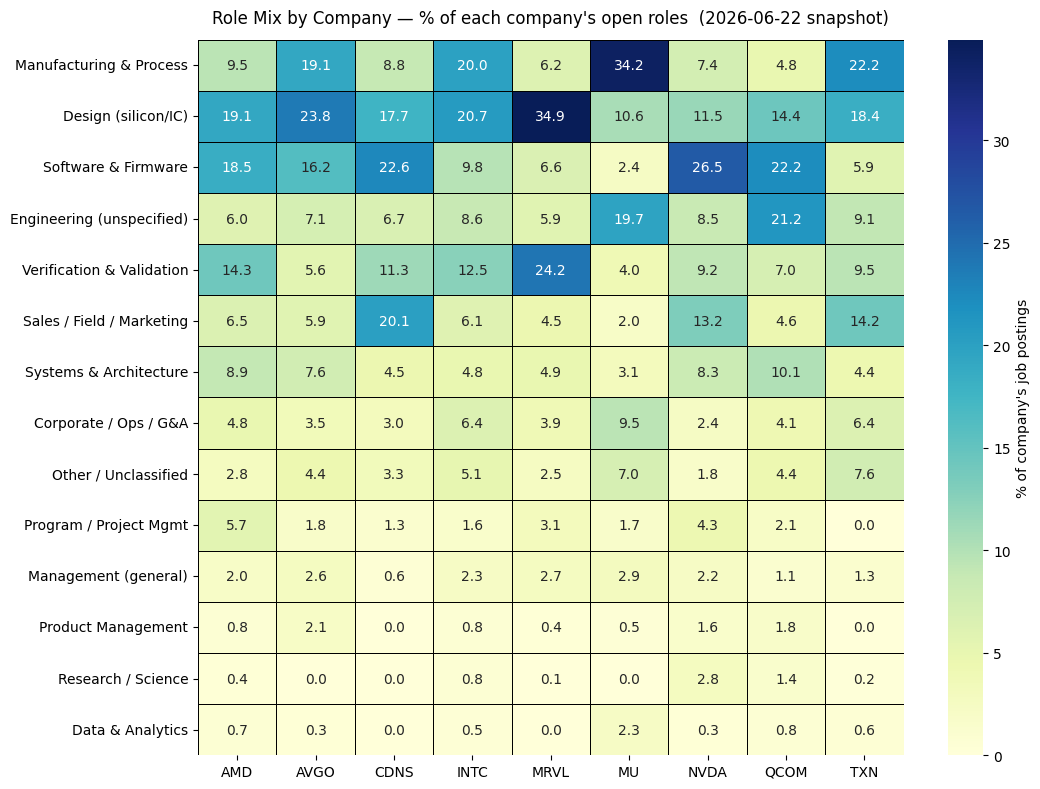

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# rebuild mix (kernel-safe — it was wiped in the restart): % of each ticker's roles per bucket
mix = pd.crosstab(df['ticker'], df['role_bucket'], normalize='index').mul(100).round(1)
mix = mix[df['role_bucket'].value_counts().index]   # rows ordered by overall size

snap = pd.read_sql("SELECT MAX(snapshot_date) AS d FROM hiring_signals", engine)['d'].iloc[0]

plt.figure(figsize=(11, 8))
sns.heatmap(
    mix.T,                       # buckets as rows, tickers as columns — scan a role across companies
    annot=True, fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.7, linecolor='black',
    cbar_kws={'label': "% of company's job postings"}
)
plt.title(f"Role Mix by Company — % of each company's open roles  ({snap} snapshot)",
          fontsize=12, pad=12)
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.savefig("role_mix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()